In [361]:
import numpy as np 
import pandas as pd
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

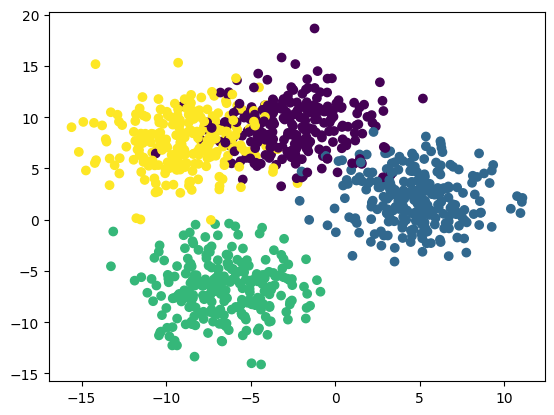

In [ ]:
df = make_blobs(n_samples=1000, n_features=2, centers=4 , cluster_std=2.5, random_state=42)

X = df[0]
y = df[1]
plt.scatter(X[:,0], X[:,1], c=y)

In [363]:
p = int(len(X)*0.75)
X_train, y_train = X[0:p], y[0:p]
X_test, y_test = X[p:], y[p:]

print(X_train.shape, y_train.shape, X_test.shape , y_test.shape)

(750, 2) (750,) (250, 2) (250,)


In [364]:
class Kmeans():
    def __init__(self, k):
        self.k = k
        self.costs = []
                
    def Initialization(self, k, X):
        self.clusters = X[np.random.choice(len(X), self.k, replace=False)]      
          
    def predict(self, X):
        return np.argmin(np.linalg.norm((X[:, None] - self.clusters), axis=2), axis=1)
    
    def update(self, X, pred):
        preds = self.predict(X)
        for cls in range(self.k):
            self.clusters[cls] = np.mean(X[preds == cls], axis=0)
        return self.clusters
            
    def fit(self, X, iter):
        self.Initialization(self.k, X)
        pred = self.predict(X)
        for i in range(iter):
            self.clusters = self.update(X, pred)
        

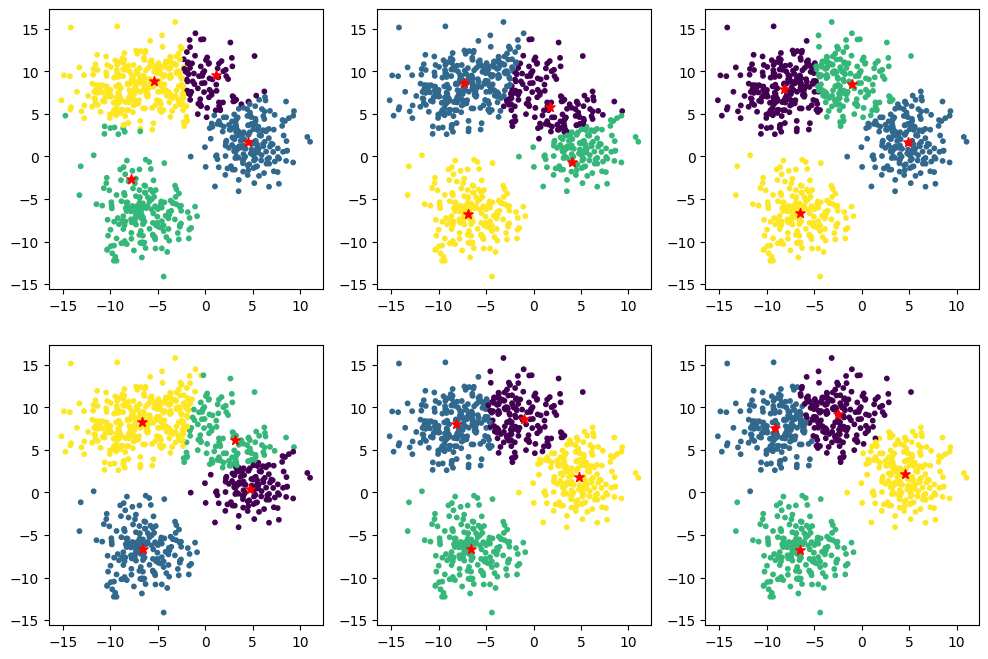

In [365]:
fig, axs = plt.subplots(2,3, figsize=(12,8))

for j, i in enumerate(range(2, 8)):
    model = Kmeans(4)
    model.fit(X_train,i)
    preds = model.predict(X_train)
    row = j // 3
    col = j % 3
    axs[row, col].scatter(X_train[:,0], X_train[:,1], c=preds, s=10)
    axs[row, col].scatter(model.clusters[:,0],model.clusters[:,1], marker="*", color="red", s=50)

In [367]:
from sklearn.metrics import accuracy_score
model = Kmeans(4)
model.fit(X_train,10)
print(f"accuracy: {accuracy_score(y_test, model.predict(X_test))}")

accuracy: 0.936
